# Test the model on my own handwriting

Loads the model trained in `handwritten_recognition.ipynb` (no retraining) and tests it on photos/scans of handwritten letters.

**How to use**
1. Write the alphabet with a dark pen, leaving clear gaps between letters (touching letters merge into one blob).
   Plain or ruled paper both work: ruled lines are removed automatically.
2. Photograph it straight-on in even light, and save it as JPG or PNG in `my_samples/`.
3. In the config cell, add the file to `TESTS`: which region of the photo holds which text. Regions let one photo hold several
   alphabets and leave out anything else on the page (printed text, the table behind the paper).
4. Run all cells.

Pipeline per region: **find ink → remove ruled lines → split into characters → put in reading order → convert each to EMNIST format → predict → score**.

## 1. Setup and load the trained model

In [1]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageOps, ImageFilter
from scipy import ndimage
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

# must match the architecture in handwritten_recognition.ipynb
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(),
                nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(),
                nn.MaxPool2d(2), nn.Dropout(0.25),
            )
        self.features = nn.Sequential(block(1, 32), block(32, 64))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 7 * 7, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

MODEL_PATH = "models/cnn_emnist_balanced.pt"
ckpt = torch.load(MODEL_PATH, map_location="cpu")
classes, MEAN, STD = ckpt["classes"], ckpt["mean"], ckpt["std"]
model = CNN(len(classes))
model.load_state_dict(ckpt["state_dict"])
model.to(device).eval()
print(f"loaded {MODEL_PATH}: {len(classes)} classes on {device}")

loaded models/cnn_emnist_balanced.pt: 47 classes on mps


In [2]:
# ---- Config ----
SAMPLES_DIR = "my_samples"

# What each image contains, keyed by file name without extension. Each image has one or more regions:
#     (label, crop, expected text)
# crop = (top, bottom, left, right) as fractions of the image, e.g. (0, 0.5, 0, 1) is the top half; None = whole image.
# Expected text is in reading order (left to right, top to bottom) with no spaces.
# Images not listed here are still read (whole image), just not scored.
TESTS = {
    "alibha": [
        ("capitals",  (0.12, 0.355, 0, 1), "ABCDEFGHIJKLMNOPQRSTUVWXYZ"),
        ("lowercase", (0.355, 0.62, 0, 1), "abcdefghijklmnopqrstuvwxyz"),
    ],
    "arav": [
        ("capitals", (0.03, 0.355, 0, 1), "ABCDEFGHIJKLMNOPQRSTUVWXYZ"),
        ("digits",   (0.355, 0.452, 0, 1), "12345678"),
        ("digit 9",  (0.452, 0.56, 0, 0.18), "9"),  # stops before the crossed-out scribble
    ],
    # "my_photo": [("capitals", None, "ABCDEFGHIJKLMNOPQRSTUVWXYZ")],
}

# Photos that are sideways or upside down: degrees to rotate counter-clockwise (90, 180 or 270) so the text is upright.
# Applied before cropping, so regions above refer to the upright image.
ROTATE = {"arav": 90}

REMOVE_LINES = True  # erase ruled-paper lines (harmless on plain paper)

# Pieces of ink this close vertically (as a fraction of letter height) and overlapping horizontally
# are joined into one character: the dot on i/j, a crossbar not touching its stem, etc.
MERGE_GAP = 0.5

## 2. Find and extract the characters

- **Find ink:** estimate the paper brightness everywhere (so shadows and uneven light don't matter), then mark pixels clearly darker than the paper.
- **Remove ruled lines:** find long thin strokes running roughly horizontally across much of the page (no letter does that), erase them,
  then re-join letter strokes that crossed a line (tails of g, j, q, y).
- **Split:** each connected blob of ink is a candidate; nearby pieces stacked vertically are merged (i/j dots, broken strokes); specks are dropped.
- **Order:** group into rows by vertical position, then sort each row left to right.
- **Convert to EMNIST format:** the model only ever saw 28×28 images with white ink on black, the character centred and filling ~23 px, with thick strokes (~1/6 of the letter size). Each crop is made to look the same, otherwise the model can fail on letters that are perfectly clear.

In [3]:
def load_gray(path, max_side=1600):
    img = ImageOps.exif_transpose(Image.open(path)).convert("L")  # exif: respect phone rotation
    img.thumbnail((max_side, max_side))
    return np.asarray(img, dtype=np.float32) / 255  # paper ≈ 1, ink ≈ 0


def otsu_threshold(values):
    hist, edges = np.histogram(values, bins=256, range=(0, 1))
    p = hist / hist.sum()
    w = np.cumsum(p)
    mu = np.cumsum(p * edges[:-1])
    between = (mu[-1] * w - mu) ** 2 / (w * (1 - w) + 1e-12)
    return edges[np.argmax(between) + 1]


def ink_mask(gray):
    # a grey closing erases thin dark strokes, leaving an estimate of the paper's brightness
    k = max(15, min(gray.shape) // 25)
    paper = ndimage.uniform_filter(ndimage.grey_closing(gray, size=(k, k)), k)
    darkness = np.clip(1 - gray / np.maximum(paper, 1e-3), 0, 1)
    t = max(otsu_threshold(darkness), 0.15)
    mask = ndimage.binary_closing(darkness > t, iterations=1)  # reconnect tiny gaps in strokes
    faint = darkness > 0.5 * t  # also catches faint printed lines in full, used only to locate them
    return mask, faint


def find_lines(faint, angles, axis, min_span, thicken=False):
    """Pixels on long straight-ish lines near the given angles. axis=1 finds horizontal lines, axis=0 vertical."""
    H, W = faint.shape
    extent = faint.shape[axis]  # page width for horizontal lines, height for vertical ones
    L = max(25, extent // 10)  # far longer than any stroke inside a single letter
    found = np.zeros_like(faint)
    # optionally thicken first, so a hairline tilted between two tested angles still fits (used for thin margin lines;
    # not for ruled lines, where it would also swallow letter strokes running along the line)
    f8 = (ndimage.binary_dilation(faint) if thicken else faint).astype(np.uint8)
    for angle in angles:  # photographed lines are tilted and slightly curved
        rot = ndimage.rotate(f8, angle, order=0, reshape=True)
        opened = ndimage.maximum_filter1d(ndimage.minimum_filter1d(rot, L, axis=axis), L, axis=axis)
        back = ndimage.rotate(opened, -angle, order=0, reshape=True)
        dy, dx = (back.shape[0] - H) // 2, (back.shape[1] - W) // 2
        found |= back[dy:dy + H, dx:dx + W].astype(bool)
    # keep only lines spanning a large part of the page (a letter's stroke never does);
    # pieces of one broken line are joined across small gaps before measuring
    along = (L, 3) if axis == 0 else (3, L)
    lab, n = ndimage.label(ndimage.binary_dilation(found, structure=np.ones(along)))
    spans = [s[axis].stop - s[axis].start - L for s in ndimage.find_objects(lab)]
    keep = [i + 1 for i, s in enumerate(spans) if s > min_span * extent]
    return found & faint & np.isin(lab, keep)  # back to the line's real thickness


def remove_ruled_lines(mask, faint):
    """Erase ruled-paper lines (and vertical margin lines) while keeping letter strokes that cross them."""
    horiz = ndimage.binary_dilation(find_lines(faint, range(-14, 15, 2), axis=1, min_span=0.3)) & mask
    vert = ndimage.binary_dilation(find_lines(faint, range(-10, 11, 2), axis=0, min_span=0.5, thicken=True)) & mask
    clean = mask & ~horiz & ~vert
    # bridge letter strokes that crossed a line: refill line pixels that have ink on both sides of the line
    kh, kv = max(9, 2 * thickness(horiz) + 3), max(9, 2 * thickness(vert.T) + 3)
    clean |= ndimage.binary_closing(clean, structure=np.ones((kh, 1))) & horiz
    clean |= ndimage.binary_closing(clean, structure=np.ones((1, kv))) & vert
    return clean


def thickness(lines):
    """Typical thickness (px) of horizontal lines: median length of their vertical runs."""
    d = np.diff(np.pad(lines.T.astype(np.int8), ((0, 0), (1, 1))), axis=1)
    starts, ends = np.nonzero(d == 1)[1], np.nonzero(d == -1)[1]
    return int(np.ceil(np.median(ends - starts))) if len(starts) else 1


def page_mask(image):
    mask, faint = ink_mask(image)
    return remove_ruled_lines(mask, faint) if REMOVE_LINES else mask


def find_characters(mask):
    labels, n = ndimage.label(mask, structure=np.ones((3, 3)))
    areas = ndimage.sum(mask, labels, range(1, n + 1))
    comps = [{"ids": [i + 1], "box": [s[0].start, s[0].stop, s[1].start, s[1].stop], "area": a}
             for i, (s, a) in enumerate(zip(ndimage.find_objects(labels), areas)) if a >= 15]
    if not comps:
        return [], labels, 0
    h_ref = np.median([c["box"][1] - c["box"][0] for c in comps])
    # drop things far bigger than a letter (page edges, ruled lines, shadows), and scraps cut off by the
    # left/right edge of the region (stubs of lines beyond a margin, page edges)
    W = mask.shape[1]
    comps = [c for c in comps if c["box"][1] - c["box"][0] < 4 * h_ref and c["box"][3] - c["box"][2] < 4 * h_ref
             and c["box"][2] > 2 and c["box"][3] < W - 2]

    # merge pieces of one letter stacked vertically:
    #  - pieces that overlap or are separated only by a hairline (a letter cut where it crossed a ruled line)
    #  - a small piece close above/below another (i/j dots, detached crossbars or tails)
    # the result may not be taller than ~2 letters, so neighbouring rows never chain together
    med_area = np.median([c["area"] for c in comps])
    is_small = lambda c: c["box"][1] - c["box"][0] < 0.6 * h_ref or c["area"] < 0.35 * med_area
    while True:
        best = None
        for i in range(len(comps)):
            for j in range(i + 1, len(comps)):
                (t1, b1, l1, r1), (t2, b2, l2, r2) = comps[i]["box"], comps[j]["box"]
                x_overlap = min(r1, r2) - max(l1, l2)
                y_gap = max(t1, t2) - min(b1, b2)  # negative when the boxes overlap vertically
                if x_overlap < 0.4 * min(r1 - l1, r2 - l2) or max(b1, b2) - min(t1, t2) > 2.2 * h_ref:
                    continue
                small = is_small(comps[i]) or is_small(comps[j])
                if y_gap < 0.25 * h_ref or (small and y_gap < MERGE_GAP * h_ref):
                    if best is None or y_gap < best[0]:
                        best = (y_gap, i, j)
        if best is None:
            break
        _, i, j = best
        a, b = comps[i], comps.pop(j)
        (t1, b1, l1, r1), (t2, b2, l2, r2) = a["box"], b["box"]
        a["ids"] += b["ids"]; a["area"] += b["area"]
        a["box"] = [min(t1, t2), max(b1, b2), min(l1, l2), max(r1, r2)]

    med_area = np.median([c["area"] for c in comps])
    comps = [c for c in comps if c["area"] >= 0.1 * med_area]  # leftover specks
    rows = [join_close_fragments(row, med_area) for row in reading_order(comps, h_ref)]
    return [c for row in rows for c in row], labels, h_ref


def join_close_fragments(row, med_area):
    # a small piece much closer to its neighbour than letters usually are to each other is part of that letter
    # (e.g. a pen stroke that skipped, splitting 'h' into a stem and a hump)
    if len(row) < 3:
        return row
    gaps = [b["box"][2] - a["box"][3] for a, b in zip(row, row[1:])]
    typical = np.median(gaps)
    out = [row[0]]
    for c, gap in zip(row[1:], gaps):
        prev = out[-1]
        if gap < 0.3 * typical and min(prev["area"], c["area"]) < 0.5 * med_area:
            (t1, b1, l1, r1), (t2, b2, l2, r2) = prev["box"], c["box"]
            prev["ids"] += c["ids"]; prev["area"] += c["area"]
            prev["box"] = [min(t1, t2), max(b1, b2), min(l1, l2), max(r1, r2)]
        else:
            out.append(c)
    return out


def reading_order(comps, h_ref):
    """Group into rows (top to bottom), each sorted left to right."""
    cy = lambda c: (c["box"][0] + c["box"][1]) / 2
    height = lambda c: c["box"][1] - c["box"][0]

    # 1) find the rows from ordinary-height letters (tails, ascenders and dots shift a tall letter's centre):
    #    sorted by vertical centre, a jump of more than 3/4 of a letter height starts a new row
    core = sorted([c for c in comps if height(c) <= 1.25 * h_ref] or comps, key=cy)
    groups = [core[:1]]
    for prev, c in zip(core, core[1:]):
        if cy(c) - cy(prev) > 0.75 * h_ref:
            groups.append([])
        groups[-1].append(c)
    bands = [(np.median([c["box"][0] for c in g]), np.median([c["box"][1] for c in g])) for g in groups]

    # 2) put every character in the row band it overlaps most (or the nearest one)
    rows = [[] for _ in bands]
    for c in comps:
        t, b = c["box"][:2]
        rows[int(np.argmax([min(b, bb) - max(t, bt) for bt, bb in bands]))].append(c)
    return [sorted(row, key=lambda c: c["box"][2]) for row in rows if row]


def to_emnist(char_mask, fill=23, rel_stroke=0.17, scale=4):
    """Convert one character's binary mask into a 28x28 EMNIST-style image (white ink on black, 0..1)."""
    h, w = char_mask.shape
    big = fill * scale  # work at 4x resolution, then downsample for smooth edges
    f = big / max(h, w)
    img = Image.fromarray((char_mask * 255).astype(np.uint8)).resize(
        (max(1, round(w * f)), max(1, round(h * f))), Image.BILINEAR)
    m = np.asarray(img) > 127

    # thicken thin pen strokes to EMNIST's stroke width
    boundary = m & ~ndimage.binary_erosion(m)
    width = 2 * m.sum() / max(boundary.sum(), 1)
    grow = int(round((rel_stroke * big - width) / 2))
    if grow > 0:
        m = ndimage.binary_dilation(m, iterations=grow)

    side = 28 * scale
    canvas = np.zeros((side, side), np.uint8)
    ys, xs = np.nonzero(m)
    m = m[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
    if max(m.shape) > big:  # dilation made it a bit bigger; shrink back to fit
        g = big / max(m.shape)
        m = np.asarray(Image.fromarray((m * 255).astype(np.uint8)).resize(
            (max(1, round(m.shape[1] * g)), max(1, round(m.shape[0] * g))), Image.BILINEAR)) > 127
    top, left = (side - m.shape[0]) // 2, (side - m.shape[1]) // 2
    canvas[top:top + m.shape[0], left:left + m.shape[1]] = m * 255

    out = Image.fromarray(canvas).filter(ImageFilter.GaussianBlur(scale / 2)).resize((28, 28), Image.BOX)
    out = np.asarray(out, dtype=np.float32)
    return out / max(out.max(), 1e-6)


def extract(mask):
    chars, labels, _ = find_characters(mask)
    crops = []
    for c in chars:
        t, b, l, r = c["box"]
        crops.append(to_emnist(np.isin(labels[t:b, l:r], c["ids"])))  # only this character's own ink
    return chars, crops

## 3. Predict and score

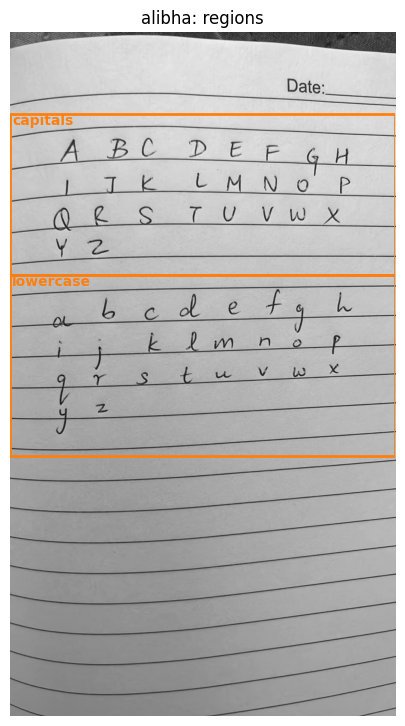

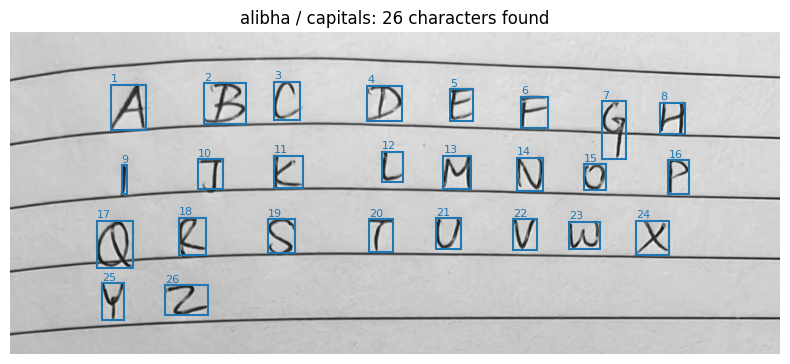

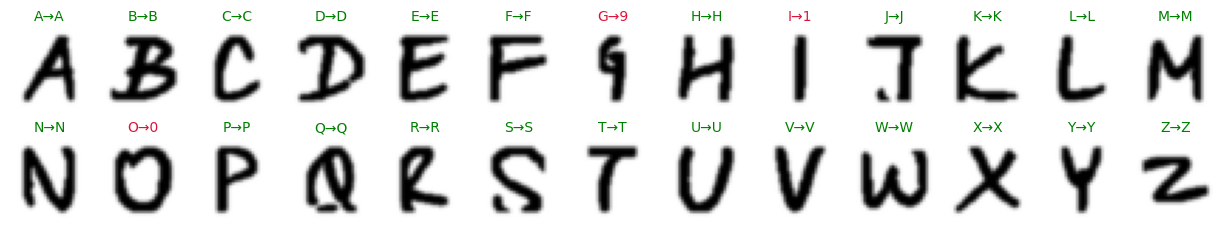

[alibha / capitals]
predicted: ABCDEF9H1JKLMN0PQRSTUVWXYZ
expected:  ABCDEFGHIJKLMNOPQRSTUVWXYZ
accuracy: 23/26 = 88%   (ignoring upper/lower case: 88%)
mistakes (model's top-3 guesses):
  box #7   'G' → 9 38%, q 37%, g 25%
  box #9   'I' → 1 55%, L 23%, I 22%
  box #15  'O' → 0 74%, O 25%, D 0%



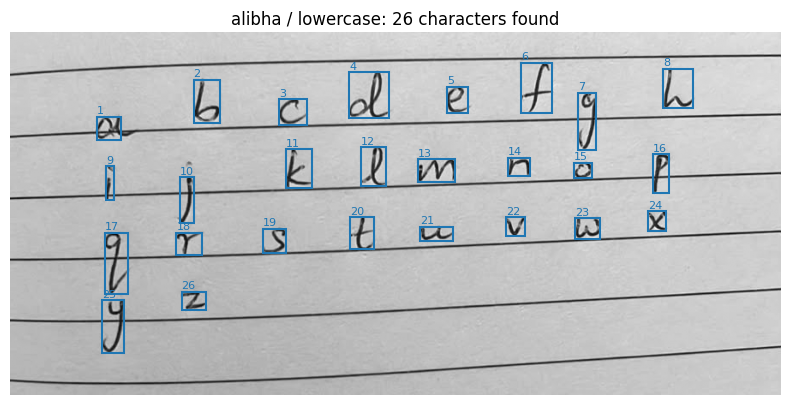

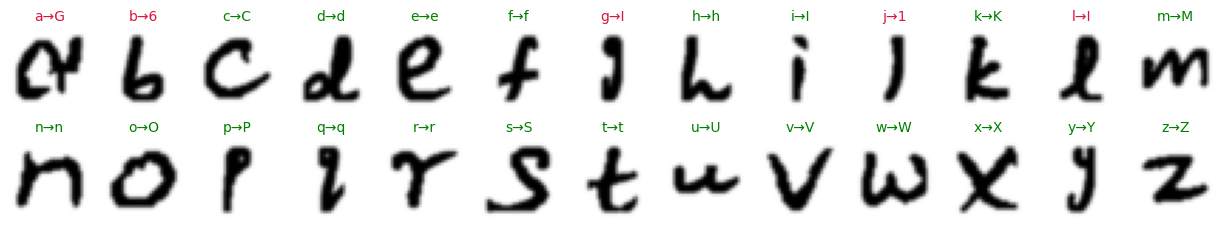

[alibha / lowercase]
predicted: G6CdefIhI1KIMnOPqrStUVWXYZ
expected:  abcdefghijklmnopqrstuvwxyz
accuracy: 21/26 = 81%   (ignoring upper/lower case: 81%)
mistakes (model's top-3 guesses):
  box #1   'a' → G 52%, d 9%, Q 8%
  box #2   'b' → 6 84%, b 16%, G 0%
  box #7   'g' → I 28%, 1 26%, J 25%
  box #10  'j' → 1 62%, L 24%, I 14%
  box #12  'l' → I 45%, L 27%, 2 16%



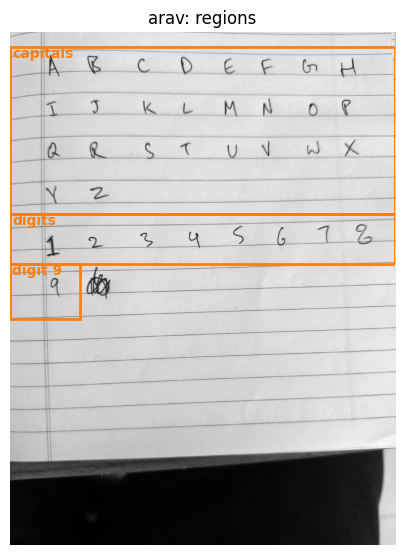

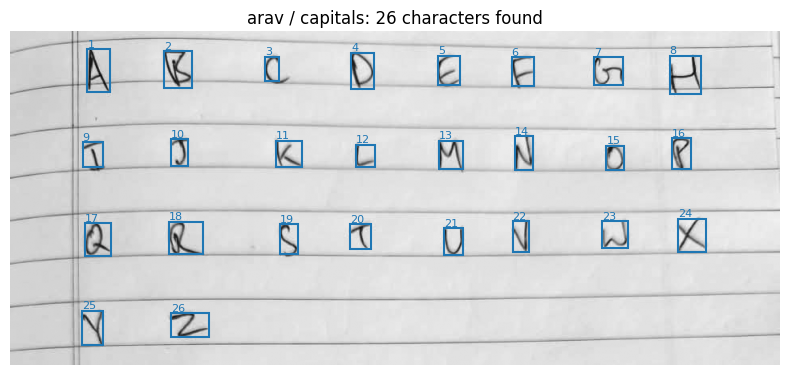

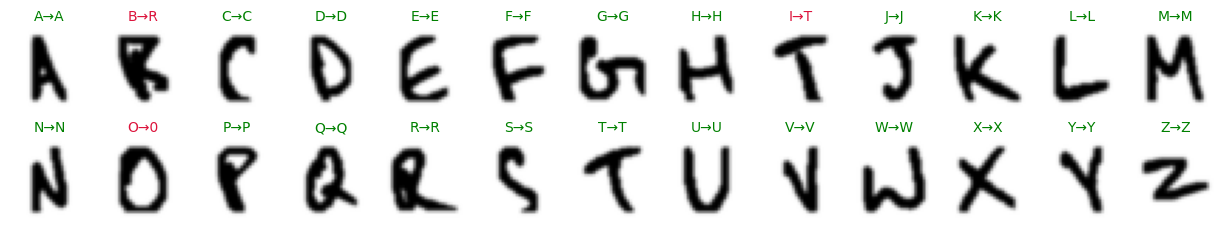

[arav / capitals]
predicted: ARCDEFGHTJKLMN0PQRSTUVWXYZ
expected:  ABCDEFGHIJKLMNOPQRSTUVWXYZ
accuracy: 23/26 = 88%   (ignoring upper/lower case: 88%)
mistakes (model's top-3 guesses):
  box #2   'B' → R 67%, q 20%, K 8%
  box #9   'I' → T 94%, J 2%, t 2%
  box #15  'O' → 0 72%, O 24%, D 4%



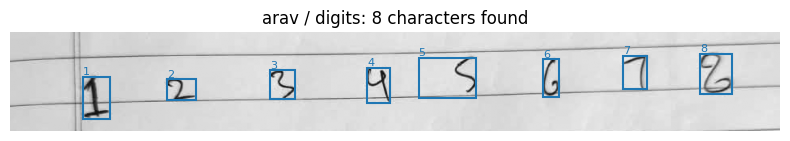

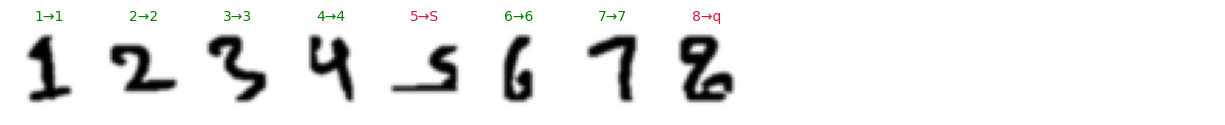

[arav / digits]
predicted: 1234S67q
expected:  12345678
accuracy: 6/8 = 75%   (ignoring upper/lower case: 75%)
mistakes (model's top-3 guesses):
  box #5   '5' → S 92%, 5 7%, J 0%
  box #8   '8' → q 98%, g 2%, 8 0%



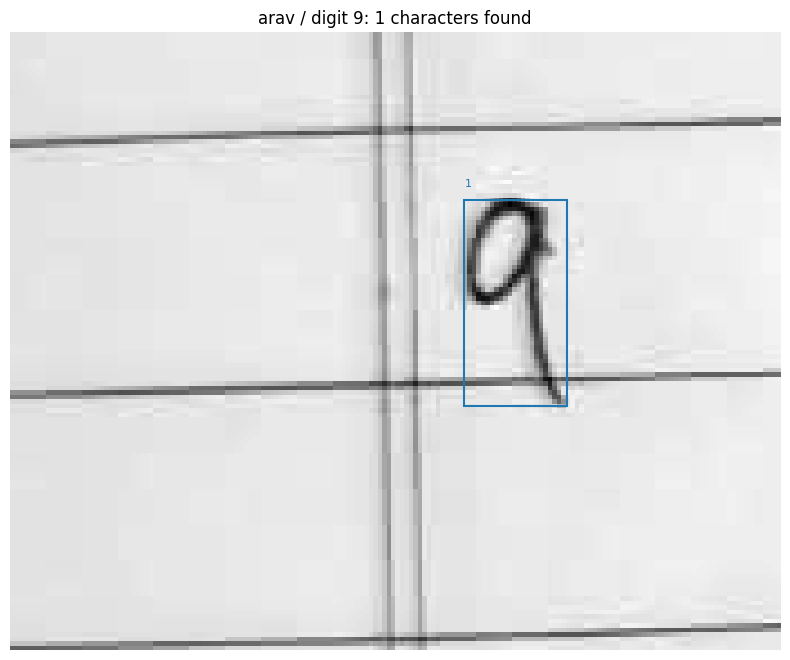

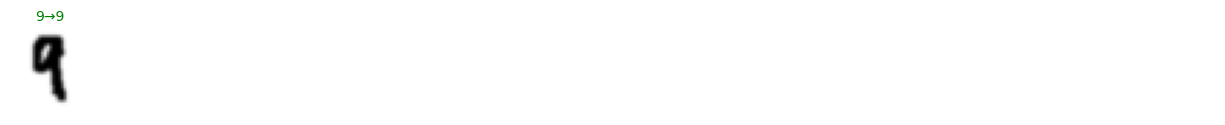

[arav / digit 9]
predicted: 9
expected:  9
accuracy: 1/1 = 100%   (ignoring upper/lower case: 100%)



In [4]:
def canonical(ch):
    # balanced EMNIST merges look-alike lowercase letters into uppercase (c→C, o→O, ...)
    return ch if ch in classes else ch.upper()


def align(expected, predicted):
    """Line up expected and predicted characters like a spell-checker (edit distance), so one extra or missing
    character doesn't shift everything after it. Returns (expected index, predicted index) pairs; None = gap."""
    n, m = len(expected), len(predicted)
    miss = lambda i, j: int(predicted[j] != canonical(expected[i]))
    cost = np.zeros((n + 1, m + 1), int)
    cost[:, 0], cost[0, :] = range(n + 1), range(m + 1)
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost[i, j] = min(cost[i - 1, j - 1] + miss(i - 1, j - 1), cost[i - 1, j] + 1, cost[i, j - 1] + 1)
    pairs, i, j = [], n, m
    while i or j:
        if i and j and cost[i, j] == cost[i - 1, j - 1] + miss(i - 1, j - 1):
            pairs.append((i - 1, j - 1)); i -= 1; j -= 1
        elif i and cost[i, j] == cost[i - 1, j] + 1:
            pairs.append((i - 1, None)); i -= 1
        else:
            pairs.append((None, j - 1)); j -= 1
    return pairs[::-1]


@torch.no_grad()
def predict(crops):
    x = (torch.tensor(np.stack(crops))[:, None] - MEAN) / STD
    return F.softmax(model(x.to(device)), dim=1).cpu()


def show_detection(gray, chars, title):
    fig, ax = plt.subplots(figsize=(10, 10 * gray.shape[0] / gray.shape[1]))
    ax.imshow(gray, cmap="gray")
    for i, c in enumerate(chars):
        t, b, l, r = c["box"]
        ax.add_patch(patches.Rectangle((l, t), r - l, b - t, fill=False, ec="tab:blue", lw=1.5))
        ax.text(l, t - 3, str(i + 1), color="tab:blue", fontsize=8)
    ax.set_title(f"{title}: {len(chars)} characters found"); ax.axis("off")
    plt.show()


def show_predictions(crops, tags):
    """Each crop as the model sees it, titled with a (text, colour) tag."""
    cols = 13
    rows = int(np.ceil(len(crops) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 0.95, rows * 1.25), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, crop, (text, colour) in zip(axes.flat, crops, tags):
        ax.imshow(crop, cmap="gray_r")
        ax.set_title(text, fontsize=10, color=colour)
    plt.tight_layout(); plt.show()


paths = sorted(p for p in glob.glob(os.path.join(SAMPLES_DIR, "*"))
               if p.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp")))
if not paths:
    print(f"No images in {SAMPLES_DIR}/ yet. Add some and re-run.")

def show_regions(image, regions, name):
    H, W = image.shape
    fig, ax = plt.subplots(figsize=(5, 5 * H / W))
    ax.imshow(image, cmap="gray")
    for label, (t, b, l, r), _ in regions:
        ax.add_patch(patches.Rectangle((l * W, t * H), (r - l) * W, (b - t) * H, fill=False, ec="tab:orange", lw=2))
        ax.text(l * W + 5, t * H + 25, label, color="tab:orange", fontsize=10, weight="bold")
    ax.set_title(f"{name}: regions"); ax.axis("off")
    plt.show()


results = {}
for path in paths:
    name = os.path.splitext(os.path.basename(path))[0]
    image = np.rot90(load_gray(path), ROTATE.get(name, 0) // 90)
    mask = page_mask(image)  # whole page, so ruled lines are found across their full length
    regions = TESTS.get(name, [(None, None, None)])
    if any(crop for _, crop, _ in regions):
        show_regions(image, [r for r in regions if r[1]], name)

    for label, crop, expected in regions:
        title = f"{name} / {label}" if label else name
        region = (slice(None), slice(None))
        if crop:
            H, W = image.shape
            t, b, l, r = crop
            region = (slice(int(t * H), int(b * H)), slice(int(l * W), int(r * W)))
        gray = image[region]
        chars, crops = extract(mask[region])
        show_detection(gray, chars, title)
        if not crops:
            print("no characters found\n"); continue

        probs = predict(crops)
        pred = [classes[p] for p in probs.argmax(1).tolist()]

        if expected is None:
            show_predictions(crops, [(p, "black") for p in pred])
            print(f"[{title}]\npredicted:", "".join(pred))
            print(f"(not scored: add '{name}' to TESTS to score it)\n"); continue

        pairs = align(expected, pred)
        tags = [None] * len(crops)
        for i, j in pairs:
            if j is not None and i is None:
                tags[j] = (f"extra: {pred[j]}", "darkorange")
            elif j is not None:
                tags[j] = (f"{expected[i]}→{pred[j]}", "green" if pred[j] == canonical(expected[i]) else "crimson")
        show_predictions(crops, tags)

        print(f"[{title}]")
        print("predicted:", "".join(pred))
        print("expected: ", expected)
        matched = [(i, j) for i, j in pairs if i is not None and j is not None]
        strict = sum(pred[j] == canonical(expected[i]) for i, j in matched)
        loose = sum(pred[j].lower() == expected[i].lower() for i, j in matched)
        results[title] = (strict, loose, len(expected))
        print(f"accuracy: {strict}/{len(expected)} = {strict / len(expected):.0%}"
              f"   (ignoring upper/lower case: {loose / len(expected):.0%})")

        extra = [j for i, j in pairs if i is None]
        missing = [i for i, j in pairs if j is None]
        if extra or missing:
            print(f"⚠️  found {len(chars)} characters for {len(expected)} expected (check the boxes above)")
            for j in extra:
                print(f"  extra:   box #{j + 1} (read as {pred[j]!r}) doesn't match any expected character")
            for i in missing:
                print(f"  missing: {expected[i]!r} was not found (counted as wrong)")
        wrong = [(i, j) for i, j in matched if pred[j] != canonical(expected[i])]
        if wrong:
            print("mistakes (model's top-3 guesses):")
            for i, j in wrong:
                top = probs[j].topk(3)
                guesses = ", ".join(f"{classes[k]} {v:.0%}" for v, k in zip(top.values.tolist(), top.indices.tolist()))
                print(f"  box #{j + 1:<3} {expected[i]!r} → {guesses}")
        print()

In [5]:
if results:
    total_strict = sum(s for s, _, _ in results.values())
    total_loose = sum(l for _, l, _ in results.values())
    total = sum(t for _, _, t in results.values())
    w = max(len(name) for name in results) + 2
    for name, (s, l, t) in results.items():
        print(f"{name:<{w}} {s:>3}/{t}  {s / t:6.1%}   case-insensitive {l / t:6.1%}")
    print(f"{'overall':<{w}} {total_strict:>3}/{total}  {total_strict / total:6.1%}   case-insensitive {total_loose / total:6.1%}")
    print(f"\n(for reference, accuracy on the EMNIST test set was {0.8994:.1%})")

alibha / capitals     23/26   88.5%   case-insensitive  88.5%
alibha / lowercase    21/26   80.8%   case-insensitive  80.8%
arav / capitals       23/26   88.5%   case-insensitive  88.5%
arav / digits          6/8   75.0%   case-insensitive  75.0%
arav / digit 9         1/1  100.0%   case-insensitive 100.0%
overall               74/87   85.1%   case-insensitive  85.1%

(for reference, accuracy on the EMNIST test set was 89.9%)


## Reading the results
- **The boxed image** shows what was detected as a character and in what order (box numbers are used in the mistake list).
- **Scoring** lines up the predicted and expected text like a spell-checker, so a stray mark or a letter split in two shows up as one
  **extra** (orange in the grid) instead of shifting every later letter; a letter that wasn't found is **missing** and counts as wrong.
  Many extras/missing letters mean the extraction needs help: more space between letters, better lighting, a tighter region, or `MERGE_GAP`.
- **The grid** shows exactly what the model sees: each letter after conversion to EMNIST format. If these look very different from the
  training samples in the main notebook (much thinner, off-centre, cut off), the mistake is in preparation, not the model.
- **Case-insensitive score:** the model has separate classes for some lowercase letters (a b d e f g h n q r t) and merges the rest into
  uppercase, so a lowercase `a` predicted as `A` counts as wrong in the strict score but right in the case-insensitive one.